In [1]:
from pathlib import Path
import numpy as np
import polars as pl
from sklearn.preprocessing import LabelEncoder
from src.tennis import fetch_jeff_sackmann_atp_data, read_tennis_data

In [2]:
files = fetch_jeff_sackmann_atp_data(dest_dir="data/atp_raw", start_year=2000, end_year=2025)

In [3]:
df_tennis = read_tennis_data(files)

In [4]:
df_tennis = df_tennis.with_columns([
    df_tennis["tourney_date"].cast(str).str.strptime(pl.Date, "%Y%m%d").alias("date"),
    (df_tennis['w_1stWon'] + df_tennis['w_2ndWon']).alias("w_serve_won"),
    (df_tennis['l_1stWon'] + df_tennis['l_2ndWon']).alias("l_serve_won"),
    ])

In [5]:
# drop davis cup (D)
# drop final/season ending events (F) 
df_tennis['tourney_level'].value_counts()

tourney_level,count
str,u32
"""A""",40847
"""O""",64
"""G""",12573
"""M""",13998
"""D""",6987
"""F""",437


In [7]:
server_names = np.concatenate([
    df_tennis['winner_id'].to_numpy(),
    df_tennis['loser_id'].to_numpy()
])

returner_names = np.concatenate([
    df_tennis['loser_id'].to_numpy(),
    df_tennis['winner_id'].to_numpy()
])

In [8]:
player_id_encoder = LabelEncoder()

server_ids = player_id_encoder.fit_transform(server_names)
returner_ids = player_id_encoder.transform(returner_names)

In [9]:
winner_serve_won = df_tennis['w_serve_won'].to_numpy()
winner_serve_total = df_tennis['w_svpt'].to_numpy()
loser_serve_won = df_tennis['l_serve_won'].to_numpy()
loser_serve_total = df_tennis['l_svpt'].to_numpy()

# Basic Hierarchial Regression 

Note: This work is inspired and built off some tennis bayesian work I've seen by Martin Ingram. My goal here is to get more fluent with numpyro. 

Link 1: https://martiningram.github.io/historical-serve-return/  
Link 2: https://martiningram.github.io/papers/bayes_point_based.pdf  

In [11]:
from jax import random 
import numpyro 
import numpyro.distributions as dist

/Users/msubbaiah/Documents/tennis_bayes/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
def basic_serve_return_model(X_intercept, n_players, server_idx, returner_idx, serve_attempts, serve_pts_won):
    """
    Hierarchical model with separate serve and return effects for each player.
    Args:
        Intercept: prior mean for intercept
        players_n: number of players
        server_idx: array of server indices (0-based)
        returner_idx: array of returner indices (0-based)
        y: binary outcome (1=server wins point, 0=loses)
    """
    # Intercept
    intercept = numpyro.sample("intercept", dist.Normal(X_intercept, 1))

    # Random Effects
    # Server
    mu_server = numpyro.sample("mu_server", dist.Normal(0, 1))
    sigma_server = numpyro.sample("sigma_server", dist.HalfNormal(1))
    with numpyro.plate("players_server", n_players):
        player_server = numpyro.sample("player_server", dist.Normal(mu_server, sigma_server))


    # Returner
    mu_return = numpyro.sample("mu_ret", dist.Normal(0, 1))
    sigma_return = numpyro.sample("sigma_ret", dist.HalfNormal(1))
    with numpyro.plate("players_returner", n_players):
        player_return = numpyro.sample("player_ret", dist.Normal(mu_return, sigma_return))

    # Combine logits
    logits = intercept + player_server[server_idx] - player_return[returner_idx]

    # Likelihood
    numpyro.sample("obs", dist.Binomial(total_count=serve_attempts, logits=logits), obs=serve_pts_won)    

In [24]:
# note define model dict 
# prep the model info from function 
model_dct = {
    'X_intercept': 1,
    'n_players': len(player_id_encoder.classes_),    
    'server_idx': server_ids + 1,
    'returner_idx': returner_ids + 1,
    'serve_attempts': np.concatenate([winner_serve_total, loser_serve_total]).astype(np.int32),
    'serve_pts_won': np.concatenate([winner_serve_won, loser_serve_won]).astype(np.int32)    
}

/var/folders/_7/3hw2lssx4zjb6_p04ljvgyjw0000gn/T/ipykernel_6174/3297196930.py:8: RuntimeWarning: invalid value encountered in cast
  'serve_attempts': np.concatenate([winner_serve_total, loser_serve_total]).astype(np.int32),
/var/folders/_7/3hw2lssx4zjb6_p04ljvgyjw0000gn/T/ipykernel_6174/3297196930.py:9: RuntimeWarning: invalid value encountered in cast
  'serve_pts_won': np.concatenate([winner_serve_won, loser_serve_won]).astype(np.int32)


In [33]:
from src.model_helpers import model_prep_svi, svi_conv_plot
from numpyro.infer import autoguide

In [ ]:
svi_iters = 10000
adam_lr = 0.001
# note - use low rank, its faster when we have a lot of records
guide, basic_sv = model_prep_svi(basic_serve_return_model, iterations = svi_iters, lr = adam_lr, 
                                 guide_fn = autoguide.AutoLowRankMultivariateNormal)

In [30]:
basic_sv_results = basic_sv.run(random.PRNGKey(1), svi_iters, **model_dct)

100%|██████████| 10000/10000 [00:40<00:00, 248.03it/s, init loss: 3408090.7500, avg. loss [9501-10000]: 442916.5312]



TypeError: cannot unpack non-iterable Axes object

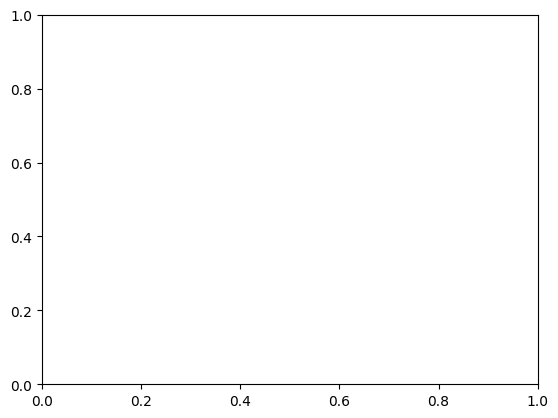

In [34]:
svi_conv_plot(basic_sv_results, 'Basic Serve/Return')

# Hierarchial Regression w/Time Component 

Goal: To get player effects varying over time. 

(1) AR(1) Covariance in MultiVariate Normal    
(2) State Space Model   